In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('co2.csv')

In [39]:
features = [
    'Engine Size(L)',
    'Cylinders',
    'Fuel Consumption City (L/100 km)',
    'Fuel Consumption Hwy (L/100 km)',
    'Fuel Consumption Comb (L/100 km)',
]

target = 'CO2 Emissions(g/km)'

In [40]:
x = df[features].values
y = df[target].values
print(x.shape, y.shape)

(7385, 5) (7385,)


In [41]:
np.random.seed(35)

indices = np.random.permutation(len(x))

split = int(0.8*len(x))
train_split = indices[:split]
test_split = indices[split:]

x_train = x[train_split]
x_test = x[test_split]
y_train = y[train_split]
y_test = y[test_split]

In [42]:
x_train = np.column_stack((np.ones(x_train.shape[0]), x_train))
x_test = np.column_stack((np.ones(x_test.shape[0]), x_test))

In [43]:
beta = np.linalg.solve(x_train.T @ x_train, x_train.T @ y_train)

In [44]:
y_train_pred = x_train @ beta
y_test_pred = x_test @ beta


In [45]:
y_test_pred = x_test @ beta
error_test = y_test - y_test_pred

In [46]:
ss_res = np.sum(error_test ** 2)

ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

r2 = 1 - (ss_res / ss_tot)


print("Test R2:", r2)

Test R2: 0.887066363675031


In [47]:
rmse = np.sqrt(np.mean((y_test - y_test_pred) ** 2))

print("Test RMSE:", rmse)

Test RMSE: 19.399620528059486


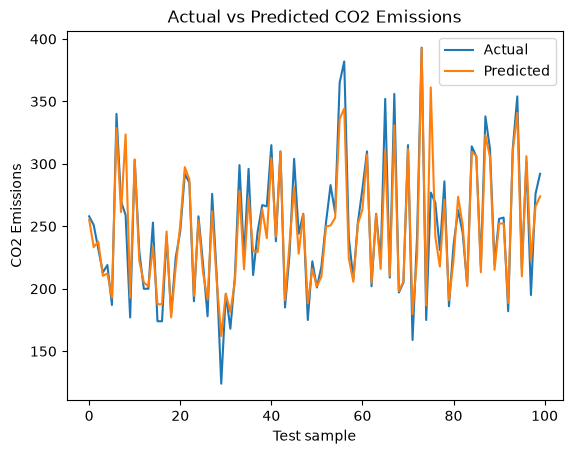

In [51]:
plt.plot(y_test[:100], label="Actual")
plt.plot(y_test_pred[:100], label="Predicted")

plt.xlabel("Test sample")
plt.ylabel("CO2 Emissions")
plt.title("Actual vs Predicted CO2 Emissions")

plt.legend()
plt.show()